# 01 — Quickstart: Loading and Visualising the SIT Battery Dataset

This notebook gets you from **zero to plotting** in under 5 minutes.  
You will learn how to:
1. Load the dataset using the `sit_utils` helper library
2. Inspect which cells and groups are available
3. Load a single charge–discharge cycle and understand its columns
4. Plot voltage, current and temperature for that cycle
5. View the capacity fade curve for one cell

In [1]:
# --- Setup ---
import sys, os
sys.path.insert(0, os.path.abspath("."))   # so sit_utils is importable

from sit_utils import SITDataset
import matplotlib.pyplot as plt

# Point to the Data root (sibling folder to Code/)
DATA_ROOT = os.path.abspath("../Data")
ds = SITDataset(DATA_ROOT)
print(ds)

SITDataset(root='c:\Users\abhirami\OneDrive - Newcastle University\Phd\PhD - Karthickumar\battery\data\SIT_Data\Batery Degradation data NYP\Data', cells=22)


## 1. What's in the dataset?

In [2]:
# List all available cells
print("All cells:", ds.list_cells())
print()

# Filter by group
for g in ["G1", "G2", "G3", "G4"]:
    print(f"{g}: {ds.list_cells(g)}")

All cells: ['001-1', '001-2', '001-3', '001-4', '001-5', '001-6', '001-7', '001-8', '002-1', '002-2', '002-3', '002-4', '002-5', '002-7', '003-1', '003-3', '003-5', '003-7', '101-1', '101-3', 'ch5', 'ch7']

G1: ['001-1', '001-2', '001-3', '001-4', '001-5', '001-6', '001-7', '001-8', '101-1', '101-3']
G2: ['002-1', '002-2', '002-3', '002-4']
G3: ['002-5', '002-7', '003-1', '003-3', '003-5', '003-7']
G4: ['ch5', 'ch7']


In [3]:
# Quick summary table
ds.summary()

,cell_id,group,tester,total_cycles,initial_capacity_Ah,final_capacity_Ah,retention_pct
0,001-1,G1,Repower_001,876,52.4512,40.2198,76.68
1,001-2,G1,Repower_001,764,55.1070,48.3862,87.80
2,001-3,G1,Repower_001,788,52.5996,25.9132,49.27
3,001-4,G1,Repower_001,878,54.9594,38.9621,70.89
4,001-5,G1,Repower_001,684,55.8289,49.4038,88.49
5,001-6,G1,Repower_001,876,55.2570,47.2159,85.45
6,001-7,G1,Repower_001,876,55.1360,48.7984,88.51
7,001-8,G1,Repower_001,764,52.2448,3.5061,6.71
8,002-1,G2,Repower_002,564,54.6732,50.5094,92.38
9,002-2,G2,Repower_002,572,51.9103,46.1036,88.81


## 2. Load a single cell and inspect one cycle

In [4]:
cell = ds.get_cell("001-3")
print(cell)
print(f"Total cycles available: {cell.total_cycles}")

CellData('001-3', group=G1, tester=Repower_001, cycles=788)
Total cycles available: 788


In [5]:
# Load cycle 10 (one complete charge-discharge event)
cycle_df = cell.get_cycle(10)
print(f"Shape: {cycle_df.shape}")
cycle_df.head(10)

Shape: (3822, 6)


,time_s,voltage_V,current_A,capacity_Ah,energy_Wh,temperature_C
0,0.0,3.289093,-49.995693,0.001389,0.004568,46.9
1,1.0,3.254817,-49.997540,0.015277,0.049980,46.9
2,2.0,3.233575,-49.995693,0.029166,0.095025,46.9
3,3.0,3.215889,-49.997540,0.043055,0.139797,46.8
4,4.0,3.200862,-49.996460,0.056943,0.184347,46.8
5,5.0,3.189745,-49.997540,0.070832,0.228719,46.8
6,6.0,3.179391,-49.997540,0.084721,0.272943,46.8
7,7.0,3.170676,-50.004921,0.098609,0.317041,46.8
8,8.0,3.164370,-49.997540,0.112498,0.361034,46.8
9,9.0,3.158372,-49.995693,0.126386,0.404944,46.8


### Columns explained
| Column | Unit | Description |
|--------|------|-------------|
| `time_s` | s | Elapsed time since start of this file |
| `voltage_V` | V | Cell terminal voltage |
| `current_A` | A | Current (positive = charge, negative = discharge) |
| `capacity_Ah` | Ah | Accumulated capacity in the current step |
| `energy_Wh` | Wh | Accumulated energy |
| `temperature_C` | °C | Cell surface temperature (thermocouple) |

## 3. Plot a single charge–discharge cycle

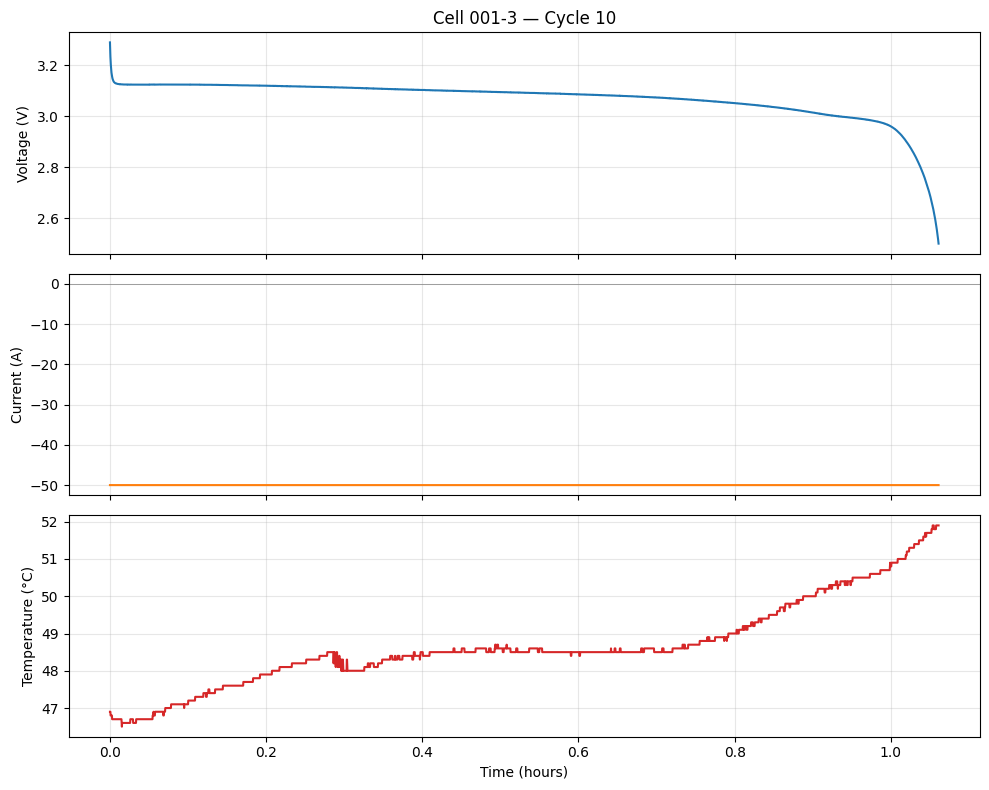

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

t = cycle_df["time_s"] / 3600   # convert to hours

axes[0].plot(t, cycle_df["voltage_V"], color="tab:blue")
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title(f"Cell 001-3 — Cycle 10")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, cycle_df["current_A"], color="tab:orange")
axes[1].set_ylabel("Current (A)")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].grid(True, alpha=0.3)

if "temperature_C" in cycle_df.columns:
    axes[2].plot(t, cycle_df["temperature_C"], color="tab:red")
axes[2].set_ylabel("Temperature (°C)")
axes[2].set_xlabel("Time (hours)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. View capacity fade for this cell

Total cycles in fade curve: 788


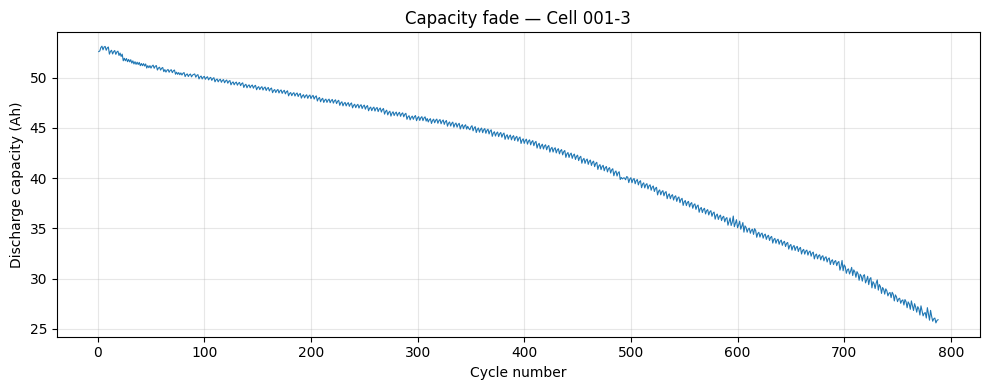

In [7]:
fade = cell.capacity_fade()
print(f"Total cycles in fade curve: {len(fade)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fade["cycle"], fade["capacity_Ah"], linewidth=0.8)
ax.set_xlabel("Cycle number")
ax.set_ylabel("Discharge capacity (Ah)")
ax.set_title(f"Capacity fade — Cell {cell.cell_id}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Compare groups at a glance

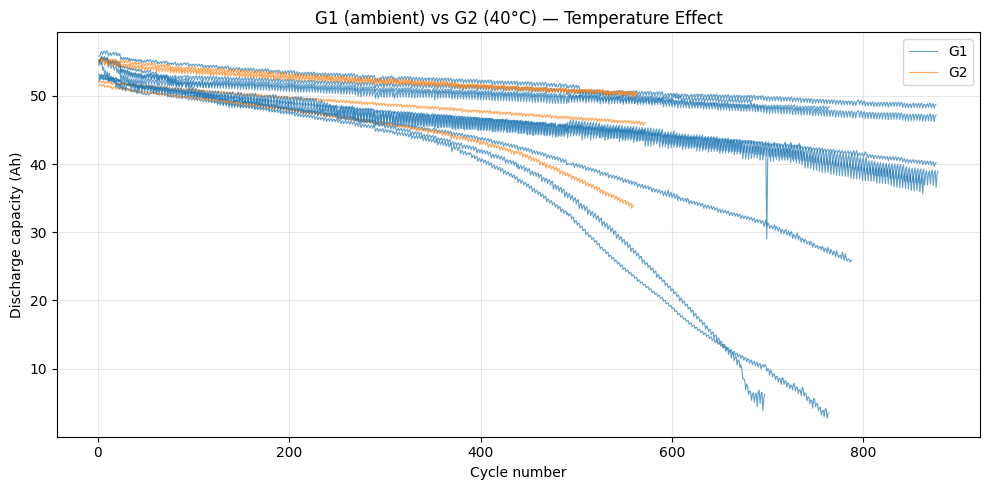

In [8]:
# Plot all G1 and G2 cells together to see temperature effect
ds.plot_capacity_fade(groups=["G1", "G2"], title="G1 (ambient) vs G2 (40°C) — Temperature Effect")
plt.tight_layout()
plt.show()

---
**Next steps:**  
→ `02_capacity_fade_analysis.ipynb` — Deep dive into degradation across all groups  
→ `03_feature_extraction.ipynb` — Build ML-ready health indicator features  
→ `04_rul_prediction.ipynb` — Train a baseline remaining useful life model